In [75]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,roc_curve,accuracy_score,f1_score,recall_score,precision_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import VotingClassifier

In [76]:
df=pd.read_csv('combined_loan_dataset.csv')
df=df[df['Loan_Status'].notna()]
df.shape

(614, 13)

In [77]:
df.isnull().sum()
df.drop('Loan_ID',axis=1,inplace=True)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 62.4+ KB


<Axes: xlabel='Loan_Amount_Term', ylabel='Density'>

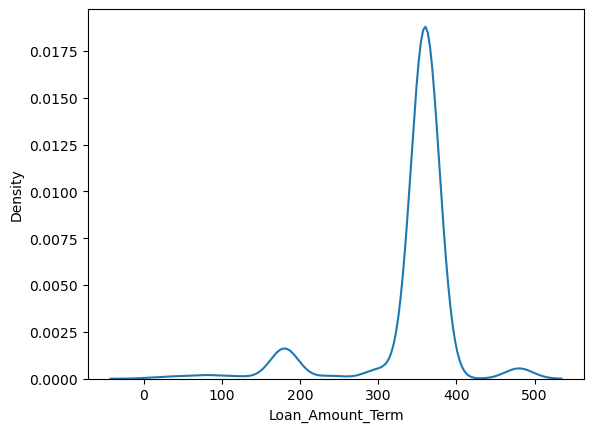

In [79]:
sns.kdeplot(df['Loan_Amount_Term'])

<Axes: xlabel='LoanAmount', ylabel='Density'>

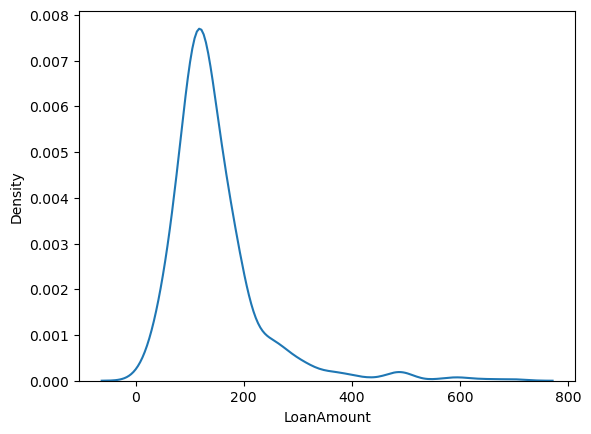

In [80]:
sns.kdeplot(df['LoanAmount'])

<Axes: xlabel='CoapplicantIncome', ylabel='Density'>

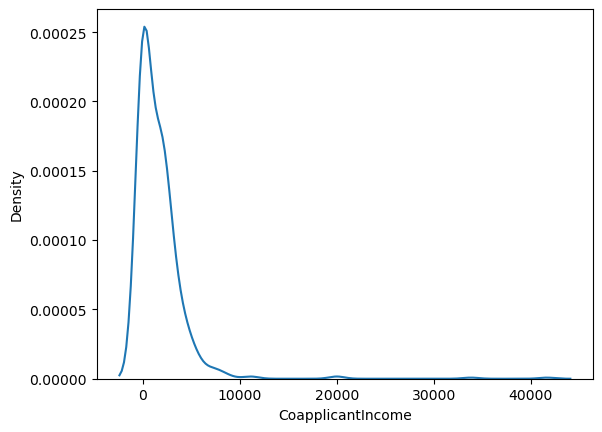

In [81]:
sns.kdeplot(df['CoapplicantIncome'])

In [82]:
#iqr method
def iq(a):
    q1=np.quantile(a,0.25)
    q3=np.quantile(a,0.75)
    iqr=q3-q1
    minimum=q1-(1.5*iqr)
    maximum=q3+(1.5*iqr)
    return a[(a>minimum) & (a<maximum)]



In [83]:
df2=iq(df['LoanAmount'])

In [84]:
df2.size


0

In [85]:
y = df['Loan_Status'].map({
    'Y': 1,
    'N': 0
})
x_train1,x_test,y_train1,y_test=train_test_split(df.iloc[: , :-1],y,test_size=0.2)

sample =RandomOverSampler()

x_train, y_train = sample.fit_resample(x_train1, y_train1)

In [86]:
categorical=Pipeline([('cat',SimpleImputer(strategy='most_frequent')),('ohe',OneHotEncoder(sparse_output=False))])
numerical=Pipeline([('num',SimpleImputer(strategy='median')),('st',StandardScaler())])#imputing

In [87]:
ct=ColumnTransformer(transformers=[
    ('ct',categorical,['Gender','Married','Dependents','Self_Employed','Credit_History','Education','Property_Area']),
    ('imputenum',numerical,['Loan_Amount_Term','LoanAmount','ApplicantIncome','CoapplicantIncome'])
],remainder='passthrough'
)

In [88]:
model=RandomForestClassifier(random_state=42)

In [89]:
final_pip = Pipeline([
    ('preprocess', ct),
    ('m', model)
])

In [90]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'm__n_estimators': [100, 200, 300],
    'm__max_depth': [3, 5, 10, None],
    'm__min_samples_split': [2, 5, 10],
    'm__min_samples_leaf': [1, 2, 5],
    'm__max_features': ['sqrt', 'log2'],
    'm__class_weight': [
        None,
        'balanced',
        {0:2, 1:1},
        {0:3, 1:1}
    ]
}

grid = GridSearchCV(
    estimator=final_pip,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ct',
                                                                         Pipeline(steps=[('cat',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(sparse_output=False))]),
                                                                         ['Gender',
                                                                          'Married',
                                                                          'Dependents',
                                                                          'Self_Employed',
                                                                          'Credit_History',
                                                                          'Education',
                                                                          'Property_Area']),
                                                                        ('imputenum',
                                                                         Pipeline(ste...
                                                                          'LoanAmount',
                                                                          'ApplicantIncome',
                                                                          'CoapplicantIncome'])])),
                                       ('m',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'m__class_weight': [None, 'balanced', {0: 2, 1: 1},
                                             {0: 3, 1: 1}],
                         'm__max_depth': [3, 5, 10, None],
                         'm__max_features': ['sqrt', 'log2'],
                         'm__min_samples_leaf': [1, 2, 5],
                         'm__min_samples_split': [2, 5, 10],
                         'm__n_estimators': [100, 200, 300]},
             scoring='f1')

In [91]:
grid.best_score_

0.8975137873124384

In [92]:
best=grid.best_estimator_

In [93]:
y_pred=best.predict(x_test)

In [94]:


c=confusion_matrix(y_test, y_pred)
accuracy_score(y_test, y_pred)

0.7479674796747967

In [95]:
c

array([[16, 22],
       [ 9, 76]], dtype=int64)

In [96]:
f1_score(y_test,y_pred)

0.8306010928961749

In [97]:
recall_score(y_test,y_pred)

0.8941176470588236

In [98]:
precision_score(y_test,y_pred)

0.7755102040816326

In [99]:
grid.best_params_

{'m__class_weight': {0: 3, 1: 1},
 'm__max_depth': None,
 'm__max_features': 'sqrt',
 'm__min_samples_leaf': 1,
 'm__min_samples_split': 2,
 'm__n_estimators': 100}

In [100]:
model2=GradientBoostingClassifier()

In [101]:
final_pip2 = Pipeline([
    ('preprocess', ct),
    ('m2', model2)
])

In [102]:
param_grid2 = {
    'm2__n_estimators': [50, 100, 200],
    'm2__learning_rate': [0.01, 0.05, 0.1],
    'm2__max_depth': [2, 3, 4],
    'm2__min_samples_split': [2, 5, 10],
    'm2__min_samples_leaf': [1, 2, 4],
    'm2__subsample': [0.8, 1.0]
}

In [103]:
grid2 = GridSearchCV(
    estimator=final_pip2,
    param_grid=param_grid2,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [104]:
grid2.fit(x_train,y_train)

C:\Users\SURAJ\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ct',
                                                                         Pipeline(steps=[('cat',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(sparse_output=False))]),
                                                                         ['Gender',
                                                                          'Married',
                                                                          'Dependents',
                                                                          'Self_Employed',
                                                                          'Credit_History',
                                                                          'Education',
                                                                          'Property_Area']),
                                                                        ('imputenum',
                                                                         Pipeline(ste...
                                                                                          StandardScaler())]),
                                                                         ['Loan_Amount_Term',
                                                                          'LoanAmount',
                                                                          'ApplicantIncome',
                                                                          'CoapplicantIncome'])])),
                                       ('m2', GradientBoostingClassifier())]),
             n_jobs=-1,
             param_grid={'m2__learning_rate': [0.01, 0.05, 0.1],
                         'm2__max_depth': [2, 3, 4],
                         'm2__min_samples_leaf': [1, 2, 4],
                         'm2__min_samples_split': [2, 5, 10],
                         'm2__n_estimators': [50, 100, 200],
                         'm2__subsample': [0.8, 1.0]},
             scoring='f1')

In [105]:
grid2.best_score_

0.9054572097757176

In [106]:
fmodel=grid2.best_estimator_

In [107]:
y_pred2=fmodel.predict(x_test)

In [108]:
confusion_matrix(y_test,y_pred2)

array([[18, 20],
       [20, 65]], dtype=int64)

In [109]:
categorical2=Pipeline([('cat',SimpleImputer(strategy='most_frequent')),('ohe',OneHotEncoder(sparse_output=False))])
numerical2=Pipeline([('num',SimpleImputer(strategy='median')),('pt',PowerTransformer(method='yeo-johnson')),('st',StandardScaler())])#imputing
ct2=ColumnTransformer(transformers=[
    
    ('ct',categorical2,['Gender','Married','Dependents','Self_Employed','Credit_History','Education','Property_Area']),
    ('imputenum',numerical2,['Loan_Amount_Term','LoanAmount','ApplicantIncome','CoapplicantIncome'])
    
],remainder='passthrough'
)

In [110]:
model3=LogisticRegression()

In [111]:
final_pip3 = Pipeline([
    ('preprocess', ct2),
    ('m3', model3)
])

In [112]:
param_grid3 = {
    'm3__C': [0.01, 0.1, 1, 10, 100],
    'm3__penalty': ['l2'],
    'm3__solver': ['lbfgs', 'liblinear'],
    'm3__class_weight': [None, 'balanced']
}

In [113]:
grid3 = GridSearchCV(
    estimator=final_pip3,
    param_grid=param_grid3,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid3.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ct',
                                                                         Pipeline(steps=[('cat',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(sparse_output=False))]),
                                                                         ['Gender',
                                                                          'Married',
                                                                          'Dependents',
                                                                          'Self_Employed',
                                                                          'Credit_History',
                                                                          'Education',
                                                                          'Property_Area']),
                                                                        ('imputenum',
                                                                         Pipeline(ste...,
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('pt',
                                                                                          PowerTransformer()),
                                                                                         ('st',
                                                                                          StandardScaler())]),
                                                                         ['Loan_Amount_Term',
                                                                          'LoanAmount',
                                                                          'ApplicantIncome',
                                                                          'CoapplicantIncome'])])),
                                       ('m3', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'m3__C': [0.01, 0.1, 1, 10, 100],
                         'm3__class_weight': [None, 'balanced'],
                         'm3__penalty': ['l2'],
                         'm3__solver': ['lbfgs', 'liblinear']},
             scoring='f1')

In [114]:
grid3.best_score_

0.7544075889010334

In [115]:
grid3.best_params_

{'m3__C': 0.01,
 'm3__class_weight': 'balanced',
 'm3__penalty': 'l2',
 'm3__solver': 'liblinear'}

In [116]:
fmodel3=grid3.best_estimator_

In [118]:
v=VotingClassifier(estimators=[
    ('log',fmodel3),
    ('gb',fmodel),
    ('rf',best)
],voting='soft')

In [121]:
v.fit(x_train,y_train)

VotingClassifier(estimators=[('log',
                              Pipeline(steps=[('preprocess',
                                               ColumnTransformer(remainder='passthrough',
                                                                 transformers=[('ct',
                                                                                Pipeline(steps=[('cat',
                                                                                                 SimpleImputer(strategy='most_frequent')),
                                                                                                ('ohe',
                                                                                                 OneHotEncoder(sparse_output=False))]),
                                                                                ['Gender',
                                                                                 'Married',
                                                                                 'Dependents',
                                                                                 'Self_Employed',
                                                                                 'Credit_History',
                                                                                 'Education',
                                                                                 'Property_Area']),
                                                                               ('imputenum',
                                                                                Pipe...
                                                                                ['Gender',
                                                                                 'Married',
                                                                                 'Dependents',
                                                                                 'Self_Employed',
                                                                                 'Credit_History',
                                                                                 'Education',
                                                                                 'Property_Area']),
                                                                               ('imputenum',
                                                                                Pipeline(steps=[('num',
                                                                                                 SimpleImputer(strategy='median')),
                                                                                                ('st',
                                                                                                 StandardScaler())]),
                                                                                ['Loan_Amount_Term',
                                                                                 'LoanAmount',
                                                                                 'ApplicantIncome',
                                                                                 'CoapplicantIncome'])])),
                                              ('m',
                                               RandomForestClassifier(class_weight={0: 3,
                                                                                    1: 1},
                                                                      random_state=42))]))],
                 voting='soft')

In [126]:
finalpred=v.predict(x_test)

In [127]:
confusion_matrix(y_test,finalpred)

array([[20, 18],
       [12, 73]], dtype=int64)

In [128]:
accuracy_score(y_test,finalpred)

0.7560975609756098

In [129]:
f1_score(y_test,finalpred)

0.8295454545454546

In [130]:
recall_score(y_test,finalpred)

0.8588235294117647

In [131]:
precision_score(y_test,finalpred)

0.8021978021978022

In [132]:
import joblib

joblib.dump(v, "loan_model.pkl")     # v = your voting classifier

['loan_model.pkl']

In [133]:
joblib.dump(v, "loan_pipeline.pkl")

['loan_pipeline.pkl']

In [134]:
import joblib
import pandas as pd

model = joblib.load("loan_pipeline.pkl")

def predict_loan(data):
    df = pd.DataFrame([data])
    return model.predict(df)[0]

In [ ]:
sample = {
    "Gender":"Male",
    "Married":"Yes",
    "Dependents":"0",
    "Education":"Graduate",
    "Self_Employed":"No",
    "ApplicantIncome":5000,
    "CoapplicantIncome":1500,
    "LoanAmount":120,
    "Loan_Amount_Term":360,
    "Credit_History":1,
    "Property_Area":"Urban"
}

Note: you may need to restart the kernel to use updated packages.


1.5.1
